# Train Parameterized Ratio Estimator

Train a neural network to estimate the likelihood ratio $r(x|\theta) = p(x|\theta) / p(x|\theta_{\text{ref}})$
as a function of both the observation $x$ and the theory parameter $\theta$.

**Input**: `data/lhe_data_semi_parametric_b1.h5` (MadMiner file from `semi_parametric_setup.ipynb`)

**Methods trained**: ALICES (Augmented Likelihood Inference with Cross-Entropy and Score)

**Output**: Trained model saved to `models/alices`

## 0. Setup

In [1]:
# import subprocess
# subprocess.check_call(["pip", "install", "-e", "/home/shared/madminer"])

In [2]:
import logging
import numpy as np
import matplotlib.pyplot as plt

from madminer.sampling import SampleAugmenter
from madminer.ml import ParameterizedRatioEstimator

logging.basicConfig(
    format="%(asctime)-5.5s %(name)-20.20s %(levelname)-7.7s %(message)s",
    datefmt="%H:%M",
    level=logging.INFO,
)
for key in logging.Logger.manager.loggerDict:
    if "madminer" not in key:
        logging.getLogger(key).setLevel(logging.WARNING)

## 1. Extract Training Data

Use `SampleAugmenter` to draw training samples from the MadMiner file.
For each event we get:
- $x$: observables
- $\theta_0$: numerator parameter (sampled randomly from the prior)
- $\theta_1$: denominator parameter (fixed at SM)
- $y$: class label (0 = numerator, 1 = denominator)
- $r_{xz}$: joint likelihood ratio
- $t_{xz}$: joint score $\nabla_\theta \log p(x,z|\theta)$

In [3]:
sampler = SampleAugmenter("data/lhe_data_semi_parametric_b1.h5")

print(f"Parameters:  {list(sampler.parameters.keys())}")
print(f"Benchmarks:  {list(sampler.benchmarks.keys())}")
print(f"Observables: {list(sampler.observables.keys())}")
print(f"Morphing:    {sampler.morpher is not None}")

23:51 madminer.analysis.da INFO    Loading data from data/lhe_data_semi_parametric_b1.h5
23:51 madminer.utils.inter INFO    HDF5 file does not contain finite difference information
23:51 madminer.analysis.da INFO    Found 2 parameters
23:51 madminer.analysis.da INFO      0: CWL2 (LHA: dim6 2, Power: 2, Range: (np.float64(-20.0), np.float64(20.0)))
23:51 madminer.analysis.da INFO      1: CPWL2 (LHA: dim6 5, Power: 2, Range: (np.float64(-20.0), np.float64(20.0)))
23:51 madminer.analysis.da INFO    Found 3 nuisance parameters
23:51 madminer.analysis.da INFO      0: scale_mur_nuisance_param_0 (Systematic: scale_mur, Benchmarks: scale_mur_nuisance_param_0_benchmark_0 | scale_mur_nuisance_param_0_benchmark_1)
23:51 madminer.analysis.da INFO      1: scale_muf_nuisance_param_0 (Systematic: scale_muf, Benchmarks: scale_muf_nuisance_param_0_benchmark_0 | scale_muf_nuisance_param_0_benchmark_1)
23:51 madminer.analysis.da INFO      2: scale_corr_nuisance_param_0 (Systematic: scale_corr, Benchmarks

Parameters:  ['CWL2', 'CPWL2']
Benchmarks:  ['sm', 'w', 'neg_w', 'ww', 'neg_ww', 'morphing_basis_vector_5', 'scale_corr_nuisance_param_0_benchmark_0', 'scale_corr_nuisance_param_0_benchmark_1', 'scale_muf_nuisance_param_0_benchmark_0', 'scale_muf_nuisance_param_0_benchmark_1', 'scale_mur_nuisance_param_0_benchmark_0', 'scale_mur_nuisance_param_0_benchmark_1']
Observables: ['pt_j1', 'delta_phi_jj', 'met']
Morphing:    True


In [4]:
# Training data: theta0 drawn randomly, theta1 fixed at SM
x, theta0, theta1, y, r_xz, t_xz, n_eff = sampler.sample_train_ratio(
    theta0=("random_morphing_points", (500, [
        ("flat", -20.0, 20.0),   # CWL2 prior
        ("flat", -20.0, 20.0),   # CPWL2 prior
    ])),
    theta1=("benchmark", "sm"),
    n_samples=500_000,
    folder="data/samples",
    filename="train",
    test_split=0.2,
    validation_split=0.2,
    partition="train",
)

print(f"\nTraining data:")
print(f"  x:     {x.shape}")
print(f"  theta: {theta0.shape}")
print(f"  y:     {y.shape}")
print(f"  r_xz:  {r_xz.shape}")
print(f"  t_xz:  {t_xz.shape}")
print(f"  n_eff: {n_eff:.0f}")

23:51 madminer.sampling.sa INFO    Extracting training sample for ratio-based methods. Numerator hypothesis: 500 random morphing points, drawn from the following priors: 
  theta_0 ~ flat from -20.0 to 20.0
  theta_1 ~ flat from -20.0 to 20.0, denominator hypothesis: sm
23:51 madminer.sampling.sa INFO    Starting sampling serially
23:51 madminer.sampling.sa WARNING Large statistical uncertainty on the total cross section when sampling from theta = [-0.23834136  5.9875574 ]: (0.009971 +/- 0.002322) pb (23.28852545912624 %). Skipping these warnings in the future...
23:51 madminer.sampling.sa INFO    Sampling from parameter point 25 / 500
23:51 madminer.sampling.sa INFO    Sampling from parameter point 50 / 500
23:51 madminer.sampling.sa INFO    Sampling from parameter point 75 / 500
23:51 madminer.sampling.sa INFO    Sampling from parameter point 100 / 500
23:51 madminer.sampling.sa INFO    Sampling from parameter point 125 / 500
23:51 madminer.sampling.sa INFO    Sampling from parameter


Training data:
  x:     (500000, 3)
  theta: (500000, 5)
  y:     (500000, 1)
  r_xz:  (500000, 1)
  t_xz:  (500000, 5)
  n_eff: 11


In [5]:
# Test data: also random theta0 vs SM
x_test, theta0_test, theta1_test, y_test, r_xz_test, t_xz_test, _ = sampler.sample_train_ratio(
    theta0=("random_morphing_points", (200, [
        ("flat", -20.0, 20.0),
        ("flat", -20.0, 20.0),
    ])),
    theta1=("benchmark", "sm"),
    n_samples=100_000,
    folder="data/samples",
    filename="test",
    test_split=0.2,
    validation_split=0.2,
    partition="test",
)

print(f"Test data: {x_test.shape[0]} samples")

23:51 madminer.sampling.sa INFO    Extracting training sample for ratio-based methods. Numerator hypothesis: 200 random morphing points, drawn from the following priors: 
  theta_0 ~ flat from -20.0 to 20.0
  theta_1 ~ flat from -20.0 to 20.0, denominator hypothesis: sm
23:51 madminer.sampling.sa INFO    Starting sampling serially
23:51 madminer.sampling.sa WARNING Large statistical uncertainty on the total cross section when sampling from theta = [3.8008585 3.995009 ]: (0.007550 +/- 0.003753) pb (49.70306671815854 %). Skipping these warnings in the future...
23:51 madminer.sampling.sa INFO    Sampling from parameter point 10 / 200
23:51 madminer.sampling.sa INFO    Sampling from parameter point 20 / 200
23:51 madminer.sampling.sa INFO    Sampling from parameter point 30 / 200
23:51 madminer.sampling.sa INFO    Sampling from parameter point 40 / 200
23:51 madminer.sampling.sa INFO    Sampling from parameter point 50 / 200
23:51 madminer.sampling.sa INFO    Sampling from parameter point

Test data: 100000 samples


## 2. Train ALICES Estimator

ALICES combines augmented cross-entropy classification with score regression.
The loss is $L = L_{\text{ALICE}} + \alpha \cdot L_{\text{score}}$.

The network takes $(x, \theta)$ as input and outputs $\hat{s}(x|\theta)$
where $\hat{r}(x|\theta) = (1 - \hat{s}) / \hat{s}$.

In [6]:
estimator = ParameterizedRatioEstimator(
    n_hidden=(200, 200, 200),
    activation="tanh",
)

losses_train, losses_val = estimator.train(
    method="alices",
    x="data/samples/x_train.npy",
    y="data/samples/y_train.npy",
    theta="data/samples/theta0_train.npy",
    r_xz="data/samples/r_xz_train.npy",
    t_xz="data/samples/t_xz_train.npy",
    alpha=10.0,
    n_epochs=50,
    batch_size=256,
    initial_lr=1e-3,
    final_lr=1e-5,
    validation_split=0.25,
    early_stopping=True,
    early_stopping_patience=10,
)

estimator.save("models/alices")
print("Model saved to models/alices")

23:52 madminer.ml.paramete INFO    Starting training
23:52 madminer.ml.paramete INFO      Method:                 alices
23:52 madminer.ml.paramete INFO      alpha:                  10.0
23:52 madminer.ml.paramete INFO      Batch size:             256
23:52 madminer.ml.paramete INFO      Optimizer:              amsgrad
23:52 madminer.ml.paramete INFO      Epochs:                 50
23:52 madminer.ml.paramete INFO      Learning rate:          0.001 initially, decaying to 1e-05
23:52 madminer.ml.paramete INFO      Validation split:       0.25
23:52 madminer.ml.paramete INFO      Early stopping:         True
23:52 madminer.ml.paramete INFO      Scale inputs:           True
23:52 madminer.ml.paramete INFO      Scale parameters:       True
23:52 madminer.ml.paramete INFO      Shuffle labels          False
23:52 madminer.ml.paramete INFO      Samples:                all
23:52 madminer.ml.paramete INFO    Loading training data
23:52 madminer.utils.vario INFO      Loading data/samples/theta0_t

Model saved to models/alices


## 3. Training Loss

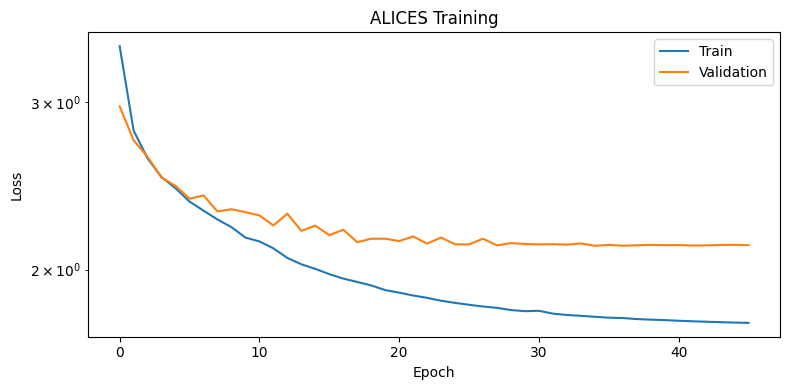

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses_train, label="Train")
ax.plot(losses_val, label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("ALICES Training")
ax.legend()
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## 4. Evaluate on Test Data

Compare predicted $\log r(x|\theta)$ against the true (morphing-based) value.

In [8]:
# Load trained model
model = ParameterizedRatioEstimator()
model.load("models/alices")

# Evaluate in batches to avoid OOM
x_test_arr = np.load("data/samples/x_test.npy")
theta_test_arr = np.load("data/samples/theta0_test.npy")

batch_size = 10_000
log_r_parts = []
for start in range(0, len(x_test_arr), batch_size):
    end = min(start + batch_size, len(x_test_arr))
    lr, _ = model.evaluate_log_likelihood_ratio(
        x=x_test_arr[start:end],
        theta=theta_test_arr[start:end],
        test_all_combinations=False,
    )
    log_r_parts.append(lr)
log_r_hat = np.concatenate(log_r_parts)

log_r_true = np.log(r_xz_test.flatten())

print(f"Predicted log r: shape={log_r_hat.shape}, mean={log_r_hat.mean():.3f}")
print(f"True log r:      shape={log_r_true.shape}, mean={log_r_true.mean():.3f}")

00:05 madminer.ml.base     INFO    Loading model from models/alices


Predicted log r: shape=(100000,), mean=0.298
True log r:      shape=(100000, 1), mean=0.317


: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted vs true
ax = axes[0]
finite = np.isfinite(log_r_true) & np.isfinite(log_r_hat)
ax.scatter(log_r_true[finite], log_r_hat[finite], alpha=0.02, s=2, rasterized=True)
lims = [max(log_r_true[finite].min(), -20), min(log_r_true[finite].max(), 20)]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlabel(r"True $\log\, r(x|\theta)$")
ax.set_ylabel(r"Predicted $\log\, \hat{r}(x|\theta)$")
ax.set_title("Predicted vs True Log Likelihood Ratio")
ax.set_xlim(lims)
ax.set_ylim(lims)

# Residual distribution
ax = axes[1]
residuals = (log_r_hat[finite] - log_r_true[finite])
ax.hist(residuals, bins=100, range=(-5, 5), density=True, alpha=0.7)
ax.axvline(0, color="r", ls="--")
ax.set_xlabel(r"$\log\,\hat{r} - \log\,r$")
ax.set_ylabel("Density")
ax.set_title(f"Residuals (mean={residuals.mean():.3f}, std={residuals.std():.3f})")

plt.tight_layout()
plt.show()

## 5. Log Likelihood Ratio Map

Evaluate $\log r(x|\theta)$ averaged over test events on a grid of $\theta$ values.

In [ ]:
# Evaluate on a theta grid using a subset of test events
x_eval = x_test[:2000]

n_grid = 25
cwl2_vals = np.linspace(-20, 20, n_grid)
cpwl2_vals = np.linspace(-20, 20, n_grid)
cwl2_grid, cpwl2_grid = np.meshgrid(cwl2_vals, cpwl2_vals)
theta_grid = np.column_stack([cwl2_grid.ravel(), cpwl2_grid.ravel()])

# Evaluate all (x, theta) combinations
log_r_grid, _ = model.evaluate_log_likelihood_ratio(
    x=x_eval,
    theta=theta_grid,
    test_all_combinations=True,
)
# log_r_grid has shape (n_theta, n_x) — average over events
mean_log_r = log_r_grid.mean(axis=1).reshape(n_grid, n_grid)

fig, ax = plt.subplots(figsize=(7, 6))
c = ax.contourf(cwl2_grid, cpwl2_grid, mean_log_r, levels=30, cmap="RdBu_r")
plt.colorbar(c, ax=ax, label=r"$\langle \log\, \hat{r}(x|\theta) \rangle_x$")
ax.plot(0, 0, "w*", markersize=15, label="SM")
ax.set_xlabel(r"$C_{W}/\Lambda^2$")
ax.set_ylabel(r"$C_{\tilde{W}}/\Lambda^2$")
ax.set_title("Mean Log Likelihood Ratio vs SM")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Expected Log Likelihood Ratio (Approximate NLL)

For SM-distributed events, compute $-2 \sum_i \log r(x_i | \theta)$ as a function of $\theta$.
This is an approximate negative log-likelihood ratio test statistic.

In [ ]:
# Use events sampled from SM (y=1 means denominator=SM)
sm_mask = (y_test.flatten() == 1)
x_sm = x_test[sm_mask][:2000]

log_r_sm, _ = model.evaluate_log_likelihood_ratio(
    x=x_sm,
    theta=theta_grid,
    test_all_combinations=True,
)

# -2 * sum of log r gives the test statistic (higher = worse fit)
nll = -2.0 * log_r_sm.sum(axis=1).reshape(n_grid, n_grid)
nll -= nll.min()  # shift so minimum is 0

fig, ax = plt.subplots(figsize=(7, 6))
c = ax.contourf(cwl2_grid, cpwl2_grid, nll, levels=30, cmap="viridis")
plt.colorbar(c, ax=ax, label=r"$-2 \sum_i \log\, \hat{r}(x_i|\theta)$ (shifted)")
# Overlay 1-sigma and 2-sigma contours (chi2 with 2 dof: 2.30, 5.99)
ax.contour(cwl2_grid, cpwl2_grid, nll, levels=[2.30, 5.99], colors=["white", "lightgray"], linewidths=2)
ax.plot(0, 0, "w*", markersize=15, label="SM (truth)")
ax.set_xlabel(r"$C_{W}/\Lambda^2$")
ax.set_ylabel(r"$C_{\tilde{W}}/\Lambda^2$")
ax.set_title(r"Approx. $-2\Delta\log L$ from Parameterized Ratio")
ax.legend()
plt.tight_layout()
plt.show()

# Find best-fit point
best_idx = np.unravel_index(nll.argmin(), nll.shape)
print(f"Best-fit: CWL2={cpwl2_grid[best_idx]:.1f}, CPWL2={cwl2_grid[best_idx]:.1f}")
print(f"(Should be near SM = (0, 0) since test events are SM-distributed)")